In [ ]:
# setup scratch dir
from pathlib import Path
from tutorial_utils import run_afqmc, get_scratch_dir

home = Path.home()
scratch_rootdir = home / ".scratch"
scratch_rootdir.mkdir(exist_ok=True)
scratch_dir = get_scratch_dir("multi_slater_trial_lattice",scratch_rootdir)

# Example: Multi-Slater determinant trial wavefunction
---

In this example, we will compute the AFQMC energy of the Hubbard model with U=8 on a 6x6x square lattice with open boundary conditions
at half-filling.
We will use a trial wavefunction consisting of two Slater determinants.
Speficially, we will use

$$
| \Psi_T \rangle = \frac{1}{\sqrt{2}} \left( |\Phi_{0}\rangle + |\Phi_{1}\rangle \right)
$$

where

$$
|\Phi_{0}\rangle = |\Phi^{UHF}\rangle = |\Phi^{\uparrow}\rangle \otimes |\Phi^{\downarrow}\rangle
$$

is the UHF ground state
and $|\Phi_{1}\rangle$ is the spin-reversed UHF ground state,

$$
|\Phi_{1}\rangle = |\Phi^{\downarrow}\rangle \otimes |\Phi^{\uparrow}\rangle
$$.

Since the Hamiltonian is spin-independent, this trial wavefunction should have the same energy as the UHF ground state.


computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


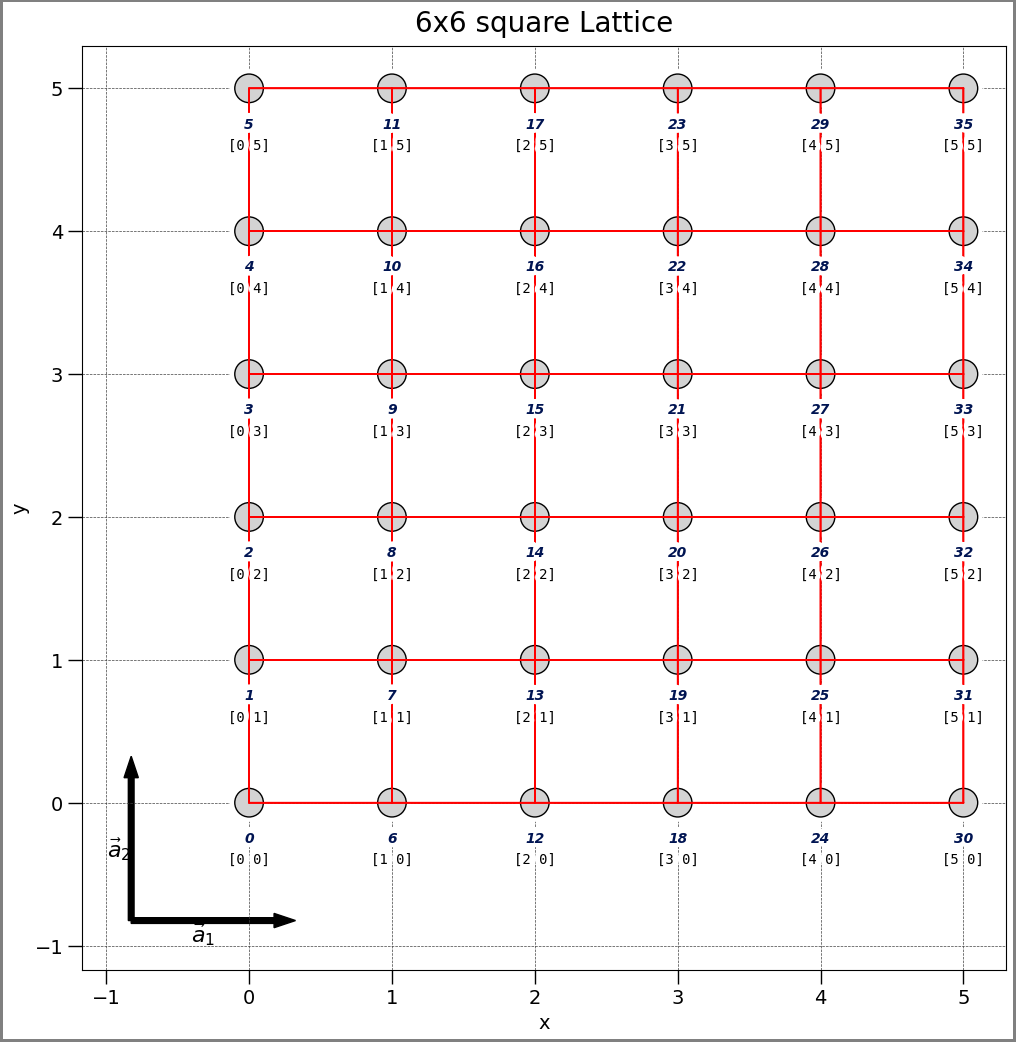

running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((8.0,))
Building Hubbard U term with U=8.0
Building onsite hubbard with positive U values: 8.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
# setup the Hamiltonian
import numpy as np

from afqmctools.systems.lattice import get_lattice
from afqmctools.utils.visualize import plot_lattice
from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io

lattice = get_lattice(
    params=dict(
        L1 = 6,
        L2 = 6,
        boundary1 = "open",
        boundary2 = "open"
    )
)

# plot the lattice for reality checks!
plot_lattice(lattice)

# define Hamiltonian parameters
hamiltonian_params = {
    'U': 8.0
}

params = {
    'hamiltonian': hamiltonian_params
}

# make the Hamiltonian
hamiltonian = HamiltonianDirector(
    source=params,
    lattice=lattice
).build()

# save for AFQMC
io.write_model_hamiltonian(hamiltonian,fname=scratch_dir/"afqmc.h5")

In [ ]:
# run autoHF to get UHF solution
from autohf.hamiltonian import AutoHFHamiltonian

Ueff = 2.75

# define effective Hamiltonian parameters
hamiltonian_params = {
    'U': 2.75
}

params = {
    'hamiltonian': hamiltonian_params
}

# make the Hamiltonian
effective_hamiltonian = HamiltonianDirector(
    source=params,
    lattice=lattice
).build()

# convert afqmctools Hamitlonian to AutoHFHamiltonian
autohf_hamiltonian = AutoHFHamiltonian(effective_hamiltonian)

running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((2.75,))
Building Hubbard U term with U=2.75
Building onsite hubbard with positive U values: 2.75
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2
Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-1.]), array([-1.])]
Added unique U terms: [2.75]


In [ ]:
from autohf import lattice_hf

nelec=(18,18)

settings = dict(
    ansatz = 'SD_ROT',
    numSteps = 100,
    nelec = nelec,
    numTrials = 100,
    seed = 42
)

results = lattice_hf(hamiltonian=autohf_hamiltonian,settings=settings)


    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                            False
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 SD_ROT
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                       42
        eta                                                       0.1
        numSteps                                                  100
        numTrials                                                 100
        plot                                        

[CpuDevice(id=0)]
default dtype: float64
nelec: (18, 18)
Using a free electron initial guess
Running in Rotation Mode
Reference HF Energy = -27.74823285289469
Initial Energy: [-27.53608424 -27.55317084 -27.5270719  -27.55020534 -27.58755593
 -27.53822055 -27.57196478 -27.56636189 -27.53068363 -27.54436325
 -27.50695162 -27.58123287 -27.58129059 -27.53187767 -27.54727809
 -27.55793945 -27.56034677 -27.54829715 -27.54848668 -27.56073501
 -27.57634462 -27.59313779 -27.57145869 -27.53546773 -27.58864435
 -27.53178232 -27.54683599 -27.55626456 -27.59268243 -27.55025801
 -27.5552706  -27.55138643 -27.52994917 -27.55570658 -27.54933742
 -27.55108179 -27.58785288 -27.56687623 -27.56915543 -27.59517712
 -27.56739889 -27.56646311 -27.55215889 -27.62025945 -27.56981615
 -27.55275364 -27.56934842 -27.53476305 -27.5791266  -27.56827231
 -27.54320118 -27.54594541 -27.57823017 -27.55383849 -27.54327807
 -27.53768452 -27.58720679 -27.59009094 -27.55999849 -27.55953635
 -27.54514233 -27.55404827 -27.53

## Construct and Save the trial wavefunction
---

<font size="4">
A trial wavefunction can be written to AuxiliaryField's HDF5 format using the `write_wfn()` function from the `afqmctools.wavefunction.common` submodule of afqmctools.
In general, the trial wavefunction in AFQMC is a linear combination of Slater determinants,
</font>

$$
|\Psi_T \rangle = \sum^{N_{det}}_n C_n | \Phi_n \rangle,
$$

<font size="4">
where
</font>
$C_n$
<font size="4">
is a complex-valued coefficient,
and $|\Phi_n\rangle$ are Slater determinants which are not necessarily
orthogonal to each other.
Here, we will specify Slater determinants as Slater matrices

&nbsp;

$$
\Phi_{ip} ≐ \begin{bmatrix}
    \bar{C}_{00} &\bar{C}_{01} & \bar{C}_{02} & \dots  & \bar{C}_{0N} \\
    \bar{C}_{10} & \bar{C}_{11} & \bar{C}_{12} & \dots  & \bar{C}_{1N} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    \bar{C}_{M0} & \bar{C}_{M1} & \bar{C}_{M2} & \dots  & \bar{C}_{MN}
\end{bmatrix},
$$
&nbsp;

<font size="4">
where $i$ is the basis index, $p$ is the electron index, and
 $M,N$ are the number of basis functions and electrons, respectively.
<b>
AuxiliaryFields uses the convention that orbitals are columns of the Slater matrices.</b>
For collinear Slater determinants, the first $N_{\uparrow}$ columns are the spin-up electrons and the last $N_{\downarrow}$ are the spin-down electrons.


In the code block below, we manually construct Slater matrices from the UHF orbitals that we got from autohf above.
</font>

In [ ]:
# construct the multi-Slater trial AND save
import numpy as np

from afqmctools.wavefunction.common import write_wfn

# get the orbitals from the AutoHF results.
orbitals_up = results[0]['orbitals'][0]
orbitals_down = results[0]['orbitals'][1]


# The columns of the Slater matrices are the HF orbitals
# Each Slater matrix has shape (Nsites x Nelec) where Nelec is N_up + N_down.
# For UHF-like Slater matrices
#     the first Nup columns are the spin-up orbitals,
#     the last Ndown columns are the spin-down orbitals
#
phi_up = orbitals_up[:,:nelec[0]]
phi_down = orbitals_down[:,:nelec[1]]


# numpy.hstack is a convenient way to concatenate the Slater matrices
phi_0 = np.hstack((phi_up, phi_down)) # |phi_0> = |phi_up> X |phi_down>

# now make the spin-reversed Slater determinant.
phi_1 = np.hstack((phi_down, phi_up)) # |phi_0> = |phi_down> X |phi_up>


C_0 = 1.0 / np.sqrt(2)

wfn = ( np.array([C_0,C_0]), np.array([phi_0,phi_1]))

write_wfn(
    filename=scratch_dir/ "afqmc.h5",
    wfn=wfn,
    walker_type="uhf",
    nelec=nelec,
    norb=lattice.N_sites
)

/mnt/ceph/users/beskridge/software/AuxiliaryFields/utils/afqmctools/wavefunction/common.py:166: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# write input file
afqmc_execution_options = {
    "timestep": 0.01,
    "steps": 10000,
    "accumlate_interval": 10,           # in units of steps
    "measure_interval": 10,             # in units of steps
    "population_control_interval" : 10, # in units of steps
    "walker_ortho_interval" : 10 ,      # in units of steps
    "n_walkers_per_mpi_task": 100,
    "seed" : 42
}

write_json(
    scratch_dir/ "afqmc.json",
    fwfn0=scratch_dir / "afqmc.h5",
    exec_opts=afqmc_execution_options
)

In [ ]:
# run AuxiliaryFields
run_afqmc(
    run_dir=scratch_dir,
    run_mode="local_cpu",
    input_file="afqmc.json",
    np=16,             # number of MPI tasks
    output_file=None   # optionally direct output to file instead of here
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
   _____               .__.__  .__                      ___________.__       .__       .___     
  /  _  \  __ _____  __|__|  | |__|____ _______ ___.__. \_   _____/|__| ____ |  |    __| _/______
 /  /_\  \|  |  \  \/  /  |  | |  \__  \_  __ <   |  |  |    __)  |  |/ __ \|  |   / __ |/  ___/
/    |    \  |  />    <|  |  |_|  |/ __ \|  | \/\___  |  |     \   |  \  ___/|  |__/ /_/ |\___ \ 
\____|__  /____//__/\_ \__|____/__(____  /__|   / ____|  \___  /   |__|\___  >____/\____ /____  >
        \/            \/               \/       \/           \/            \/           \/    \/   
=====================================================================

269.1171344409231



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/multi_slater_trial_lattice/qmc.s000.scalar.dat
[+] shebang          = #               
[+] xaxis            = time            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -16.192856 +/-   0.012412 7.30  5.0/100.0


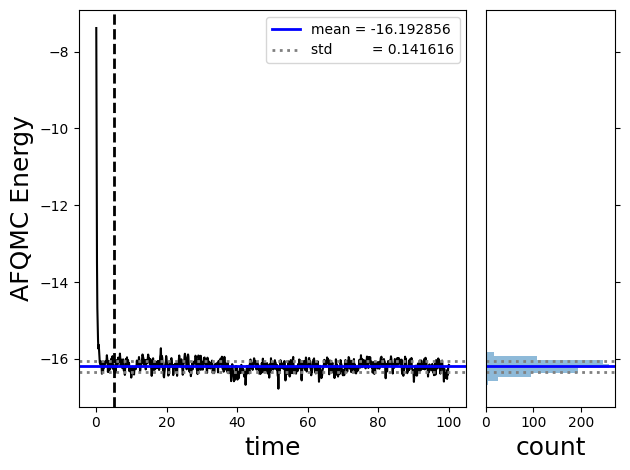

In [ ]:
# analyze results
from stats.scalar_dat import analyze_scalar_data

_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",
    nequil = 5,
    trace = True
))